In [1]:
import pymc as pm
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import arviz as az
az.style.use('arviz-darkgrid')

In [3]:
dummy_data = np.loadtxt('./date.csv')
x_1 = dummy_data[:, 0]
y_1 = dummy_data[:, 1]
order = 2
x_1p = np.vstack([x_1**i for i in range(1, order+1)])
x_1s = (x_1p - x_1p.mean(axis=1, keepdims=True))/x_1p.std(axis=1, keepdims=True)
y_1s = (y_1 - y_1.mean()) / y_1.std()

Text(0, 0.5, 'y')

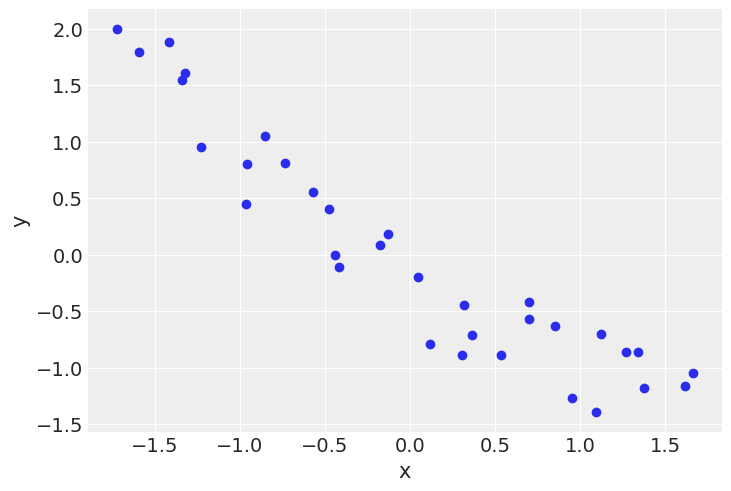

In [4]:
plt.scatter(x_1s[0], y_1s)
plt.xlabel('x')
plt.ylabel('y')

In [5]:
with pm.Model() as model_l:
    α = pm.Normal('α', mu=0, sigma=1)
    β = pm.Normal('β', mu=0, sigma=10)
    ε = pm.HalfNormal('ε', 5)
    μ = α + β * x_1s[0]
    y_pred = pm.Normal('y_pred', mu=μ, sigma=ε, observed=y_1s)
    idata_l = pm.sample(2000, return_inferencedata=True)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [α, β, ε]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 10 seconds.


In [6]:
with pm.Model() as model_p:
    α = pm.Normal('α', mu=0, sigma=1)
    β = pm.Normal('β', mu=0, sigma=10, shape=order)
    ε = pm.HalfNormal('ε', 5)
    μ = α + pm.math.dot(β, x_1s)
    y_pred = pm.Normal('y_pred', mu=μ, sigma=ε, observed=y_1s)
    idata_p = pm.sample(2000, return_inferencedata=True)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [α, β, ε]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 11 seconds.


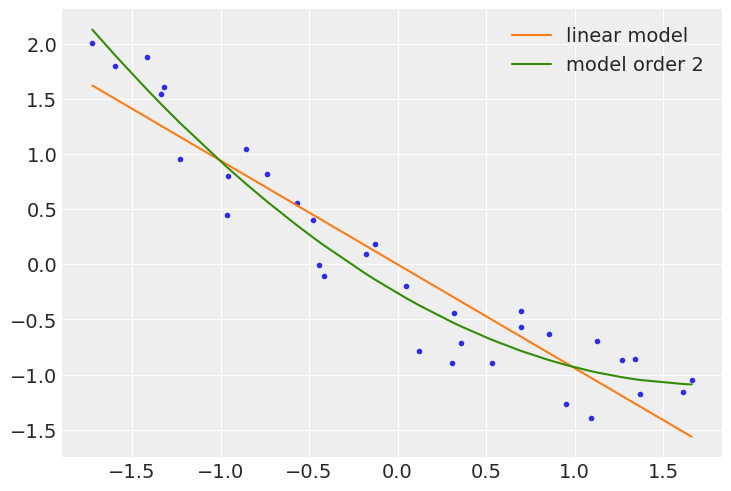

In [7]:
x_new = np.linspace(x_1s[0].min(), x_1s[0].max(), 100)

α_l_post = idata_l.posterior['α'].mean(("chain", "draw")).values
β_l_post = idata_l.posterior['β'].mean(("chain", "draw")).values
y_l_post = α_l_post + β_l_post * x_new

plt.plot(x_new, y_l_post, 'C1', label='linear model')

α_p_post = idata_p.posterior['α'].mean(("chain", "draw")).values
β_p_post = idata_p.posterior['β'].mean(("chain", "draw")).values
idx = np.argsort(x_1s[0])
y_p_post = α_p_post + np.dot(β_p_post, x_1s)

plt.plot(x_1s[0][idx], y_p_post[idx], 'C2', label=f'model order {order}')

plt.scatter(x_1s[0], y_1s, c='C0', marker='.')
plt.legend()

# Exercise 1

## Subpoint a

Our model with $order=5$

In [13]:
order=5
x_1p5 = np.vstack([x_1**i for i in range(1, order+1)])
x_1s5 = (x_1p5 - x_1p5.mean(axis=1, keepdims=True))/x_1p5.std(axis=1, keepdims=True)

In [14]:
with pm.Model() as model_p5:
    α = pm.Normal('α', mu=0, sigma=1)
    β = pm.Normal('β', mu=0, sigma=10, shape=order)
    ε = pm.HalfNormal('ε', 5)
    μ = α + pm.math.dot(β, x_1s5)
    y_pred = pm.Normal('y_pred', mu=μ, sigma=ε, observed=y_1s)
    idata_p5 = pm.sample(2000, return_inferencedata=True)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [α, β, ε]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 52 seconds.
There were 114 divergences after tuning. Increase `target_accept` or reparameterize.


Plotting the modified model

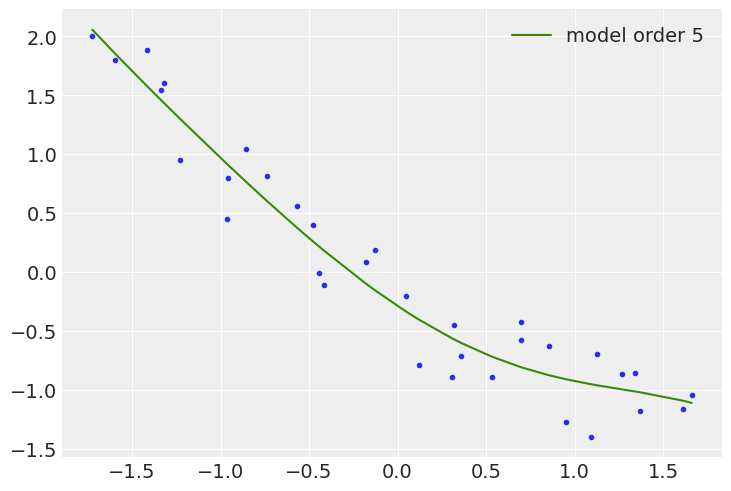

In [15]:
α_p5_post = idata_p5.posterior['α'].mean(("chain", "draw")).values
β_p5_post = idata_p5.posterior['β'].mean(("chain", "draw")).values
idx = np.argsort(x_1s[0])
y_p5_post = α_p5_post + np.dot(β_p5_post, x_1s5)

plt.plot(x_1s5[0][idx], y_p5_post[idx], 'C2', label=f'model order {order}')

plt.scatter(x_1s5[0], y_1s, c='C0', marker='.')
plt.legend()

## Subpoint b)

Declaring 2 models as follows:
- the beta is a normal distribution with standard deviation 100
- the beta distribution with standard deviation `np.array([10, 0.1, 0.1, 0.1, 0.1])`

In [16]:
with pm.Model() as model_p5_std_100:
    α = pm.Normal('α', mu=0, sigma=1)
    β = pm.Normal('β', mu=0, sigma=100, shape=order)
    ε = pm.HalfNormal('ε', 5)
    μ = α + pm.math.dot(β, x_1s5)
    y_pred = pm.Normal('y_pred', mu=μ, sigma=ε, observed=y_1s)
    idata_p5_std_100 = pm.sample(2000, return_inferencedata=True)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [α, β, ε]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 64 seconds.
There were 100 divergences after tuning. Increase `target_accept` or reparameterize.


In [18]:
with pm.Model() as model_p5_array:
    α = pm.Normal('α', mu=0, sigma=1)
    β = pm.Normal('β', mu=0, sigma=np.array([10, 0.1, 0.1, 0.1, 0.1]), shape=order)
    ε = pm.HalfNormal('ε', 5)
    μ = α + pm.math.dot(β, x_1s5)
    y_pred = pm.Normal('y_pred', mu=μ, sigma=ε, observed=y_1s)
    idata_p5_array = pm.sample(2000, return_inferencedata=True)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [α, β, ε]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 11 seconds.


Plotting

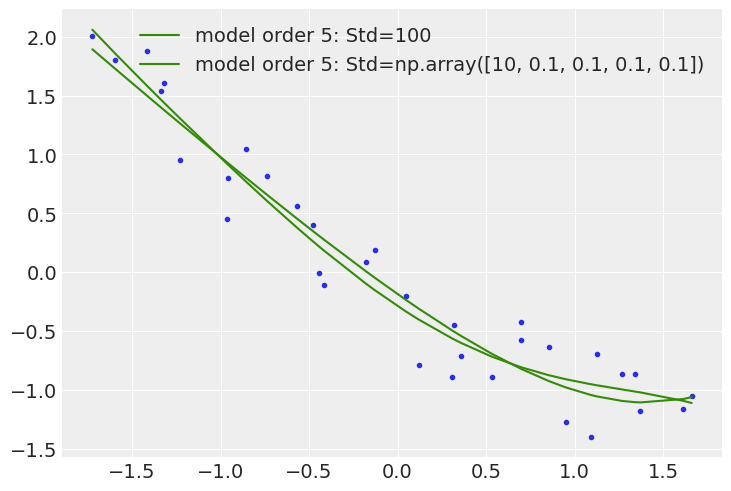

In [19]:
α_p5_post_std_100 = idata_p5_std_100.posterior['α'].mean(("chain", "draw")).values
β_p5_post_std_100 = idata_p5_std_100.posterior['β'].mean(("chain", "draw")).values
idx = np.argsort(x_1s[0])
y_p5_post_std_100 = α_p5_post_std_100 + np.dot(β_p5_post_std_100, x_1s5)

plt.plot(x_1s5[0][idx], y_p5_post_std_100[idx], 'C2', label=f'model order {order}: Std=100')

α_p5_post_array = idata_p5_array.posterior['α'].mean(("chain", "draw")).values
β_p5_post_array = idata_p5_array.posterior['β'].mean(("chain", "draw")).values
idx = np.argsort(x_1s[0])
y_p5_post_array = α_p5_post_array + np.dot(β_p5_post_array, x_1s5)

plt.plot(x_1s5[0][idx], y_p5_post_array[idx], 'C2', label=f'model order {order}: Std=np.array([10, 0.1, 0.1, 0.1, 0.1])')

plt.scatter(x_1s5[0], y_1s, c='C0', marker='.')
plt.legend()

# Exercise 2

Polynomial model of order 5 simple, with std=100, with std=`np.array([10, 0.1, 0.1, 0.1, 0.1])` this time with nr of data points=500

In [20]:
# Generate 500 data points (synthetic)
x_500 = np.linspace(-3, 3, 500)
y_500 = -2 + x_500 - 0.5 * x_500**2 + 0.1 * x_500**3 + np.random.normal(0, 1, 500)

In [21]:
# Preprocess the new data
order = 5
x_p500 = np.vstack([x_500**i for i in range(1, order+1)])
x_s500 = (x_p500 - x_p500.mean(axis=1, keepdims=True)) / x_p500.std(axis=1, keepdims=True)
y_s500 = (y_500 - y_500.mean()) / y_500.std()

In [22]:
# Model 1: Standard sigma=10
with pm.Model() as model_p5_500:
    α = pm.Normal('α', mu=0, sigma=1)
    β = pm.Normal('β', mu=0, sigma=10, shape=order)
    ε = pm.HalfNormal('ε', 5)
    μ = α + pm.math.dot(β, x_s500)
    y_pred = pm.Normal('y_pred', mu=μ, sigma=ε, observed=y_s500)
    idata_p5_500 = pm.sample(2000, return_inferencedata=True)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [α, β, ε]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 17 seconds.


In [23]:
# Model 2: Sigma=100
with pm.Model() as model_p5_std_100_500:
    α = pm.Normal('α', mu=0, sigma=1)
    β = pm.Normal('β', mu=0, sigma=100, shape=order)
    ε = pm.HalfNormal('ε', 5)
    μ = α + pm.math.dot(β, x_s500)
    y_pred = pm.Normal('y_pred', mu=μ, sigma=ε, observed=y_s500)
    idata_p5_std_100_500 = pm.sample(2000, return_inferencedata=True)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [α, β, ε]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 16 seconds.


In [24]:
# Model 3: Sigma array
with pm.Model() as model_p5_array_500:
    α = pm.Normal('α', mu=0, sigma=1)
    β = pm.Normal('β', mu=0, sigma=np.array([10, 0.1, 0.1, 0.1, 0.1]), shape=order)
    ε = pm.HalfNormal('ε', 5)
    μ = α + pm.math.dot(β, x_s500)
    y_pred = pm.Normal('y_pred', mu=μ, sigma=ε, observed=y_s500)
    idata_p5_array_500 = pm.sample(2000, return_inferencedata=True)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [α, β, ε]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 13 seconds.


Plotting

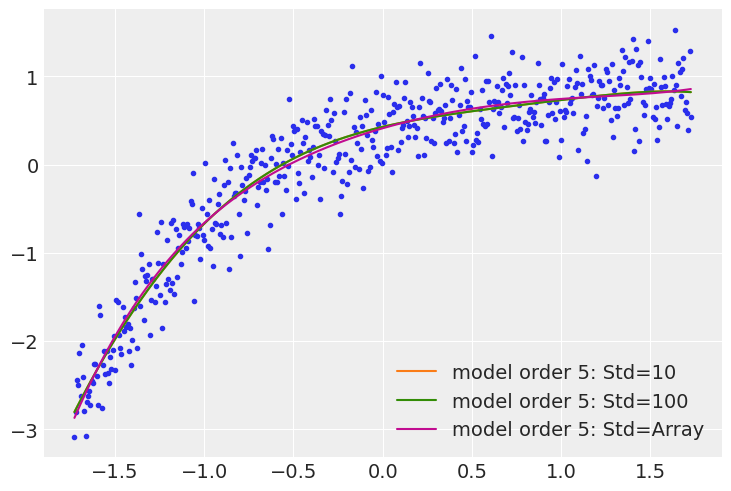

In [26]:
idx = np.argsort(x_s500[0])

α_p5_500_post = idata_p5_500.posterior['α'].mean(("chain", "draw")).values
β_p5_500_post = idata_p5_500.posterior['β'].mean(("chain", "draw")).values
y_p5_500_post = α_p5_500_post + np.dot(β_p5_500_post, x_s500)
plt.plot(x_s500[0][idx], y_p5_500_post[idx], 'C1', label=f'model order {order}: Std=10')

α_p5_std_100_500_post = idata_p5_std_100_500.posterior['α'].mean(("chain", "draw")).values
β_p5_std_100_500_post = idata_p5_std_100_500.posterior['β'].mean(("chain", "draw")).values
y_p5_std_100_500_post = α_p5_std_100_500_post + np.dot(β_p5_std_100_500_post, x_s500)
plt.plot(x_s500[0][idx], y_p5_std_100_500_post[idx], 'C2', label=f'model order {order}: Std=100')

α_p5_array_500_post = idata_p5_array_500.posterior['α'].mean(("chain", "draw")).values
β_p5_array_500_post = idata_p5_array_500.posterior['β'].mean(("chain", "draw")).values
y_p5_array_500_post = α_p5_array_500_post + np.dot(β_p5_array_500_post, x_s500)
plt.plot(x_s500[0][idx], y_p5_array_500_post[idx], 'C3', label=f'model order {order}: Std=Array')

plt.scatter(x_s500[0], y_s500, c='C0', marker='.')
plt.legend()

# Exercise 3

Creating the Cubic model $order=3$

In [29]:
order = 3
x_1pcub = np.vstack([x_1**i for i in range(1, order+1)])
x_1scub = (x_1pcub - x_1pcub.mean(axis=1, keepdims=True))/x_1pcub.std(axis=1, keepdims=True)
y_1scub = (y_1 - y_1.mean()) / y_1.std()

In [39]:
with pm.Model() as model_pcub:
    α = pm.Normal('α', mu=0, sigma=1)
    β = pm.Normal('β', mu=0, sigma=10, shape=order)
    ε = pm.HalfNormal('ε', 5)
    μ = α + pm.math.dot(β, x_1scub)
    y_pred = pm.Normal('y_pred', mu=μ, sigma=ε, observed=y_1scub)
    idata_pcub = pm.sample(2000, return_inferencedata=True)
    pm.compute_log_likelihood(idata_pcub)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [α, β, ε]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 15 seconds.
There were 3 divergences after tuning. Increase `target_accept` or reparameterize.


Output()

Plotting linear, Quad and cubic back to back

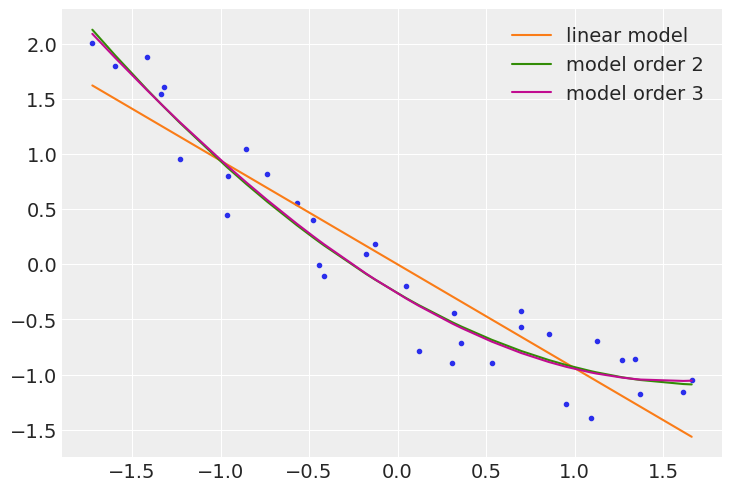

In [35]:
x_new = np.linspace(x_1s[0].min(), x_1s[0].max(), 100)

α_l_post = idata_l.posterior['α'].mean(("chain", "draw")).values
β_l_post = idata_l.posterior['β'].mean(("chain", "draw")).values
y_l_post = α_l_post + β_l_post * x_new

plt.plot(x_new, y_l_post, 'C1', label='linear model')

α_p_post = idata_p.posterior['α'].mean(("chain", "draw")).values
β_p_post = idata_p.posterior['β'].mean(("chain", "draw")).values
idx = np.argsort(x_1s[0])
y_p_post = α_p_post + np.dot(β_p_post, x_1s)

plt.plot(x_1s[0][idx], y_p_post[idx], 'C2', label=f'model order 2')

α_c_post = idata_pcub.posterior['α'].mean(("chain", "draw")).values
β_c_post = idata_pcub.posterior['β'].mean(("chain", "draw")).values
idx = np.argsort(x_1scub[0])
y_c_post = α_c_post + np.dot(β_c_post, x_1scub)

plt.plot(x_1scub[0][idx], y_c_post[idx], 'C3', label=f'model order {order}')

plt.scatter(x_1scub[0], y_1scub, c='C0', marker='.')
plt.legend()

Computing the cubic model WAIC and LOOCV 

In [40]:
waic_cubic=az.waic(idata_pcub)
print(waic_cubic)

Computed from 8000 posterior samples and 33 observations log-likelihood matrix.

          Estimate       SE
elpd_waic    -5.52     2.29
p_waic        3.35        -


In [41]:
loo_cubic=az.loo(idata_pcub)
print(loo_cubic)

Computed from 8000 posterior samples and 33 observations log-likelihood matrix.

         Estimate       SE
elpd_loo    -5.61     2.29
p_loo        3.44        -
------

Pareto k diagnostic values:
                         Count   Pct.
(-Inf, 0.70]   (good)       33  100.0%
   (0.70, 1]   (bad)         0    0.0%
   (1, Inf)   (very bad)    0    0.0%

